# Project Name :- Bird vs Drone Image Classifier (Aerial project)

project description :- 

- This project focuses on building an image classification system that can distinguish between birds and drones. The idea came from a simple problem—both can look quite similar in the sky, especially in surveillance or monitoring systems, and that can lead to incorrect decisions.

- To solve this i first worked with Convolutional Neural Network (CNN) to  extract image feature and classified them after that i improved the performance by using transfer learning with MobileNetV2, which is a pretrained model. This helped the system learn faster and perform better without needing a very large dataset.

- The dataset was organized into training, validation, and testing sets and i applied preprocessing techniques like rescaling and data augmentation to make the model more robust. Once trained i evaluated the model using accuracy and classification metrics to ensure it was working properly.

- finally i deployed the model using Streamlit, where users can upload an image and instantly get a prediction along with confidence. Since model files are large, i hosted the model on Google Drive and connected it to the app using gdown. here i used help from Chatgpt for solving file issue i faced during deploying my app into streamlit

- Overall, this project helped me understand the full pipeline of a machine learning system from data preprocessing and model building to deployment and real-time usage.


### Name - Updesh Chauhan

### Import Libraries

In [ ]:
# Import Libraries
import tensorflow as tf                                  # deep learning 
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np                                             # for numerical 
import matplotlib.pyplot as plt                                # for graphs

### Dataset Paths

In [2]:
train_dir = "train"
val_dir = "valid"
test_dir = "test"

### Data Preprocessing & Augmentation

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,          # normalize pixel 0 -1
    rotation_range=20,       # rotating image
    zoom_range=0.2,          # zoom
    horizontal_flip=True     # flip image
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

### Load Dataset

In [4]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.


Explanation:
- Here it will automatically read images from folder and resize it in 224, 224 
- shuffle=False (required for correct evaluation)

### Check Class Labels

In [5]:
print(train_data.class_indices)

{'bird': 0, 'drone': 1}


### Build Custom CNN (Convolutional Neural Network)

In [6]:
cnn_model = models.Sequential()

cnn_model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))    # detect simple features
cnn_model.add(layers.MaxPooling2D(2,2))

cnn_model.add(layers.Conv2D(64, (3,3), activation='relu'))                             # detect shapes 
cnn_model.add(layers.MaxPooling2D(2,2))

cnn_model.add(layers.Conv2D(128, (3,3), activation='relu'))                            # detect full object
cnn_model.add(layers.MaxPooling2D(2,2))

cnn_model.add(layers.Flatten())                                                        # make final decison 
cnn_model.add(layers.Dense(128, activation='relu'))
cnn_model.add(layers.Dropout(0.5))
cnn_model.add(layers.Dense(1, activation='sigmoid'))

c:\Users\updes\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Explanation
- Basically it detect edges, shapes and complex objects 
- we use "Sequential model" so Layers will be added one after another in order
- we apply 32 filter, each filter size 3×3, and convert input image size into 224*224 with 3 channel(RGB)
- it will detect edge,lines and texture
- MaxPooling2D(2,2)   :- it will help us to reduce size of image and speed up learning
- Flatten()           :- it need in Dense layering which help us to convert 2D maps into 1D vector
- layers.Dense(128)   :- it will act like decision making layer
- layers.Dropout(0.5) :- it will reduce load during it will turn off 50% work during traning model

##### layers.Dense(1, activation='sigmoid') :
         - Output = 1 value between 0 and 1
         - closer to 0 → Bird
         - closer to 1 → Drone


### Compile Model

In [7]:
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Explanation
- we use Adam Optimizer for fast convergence
- binary_crossentropy → for 2 classes

### Train Model

In [8]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 55s 638ms/step - accuracy: 0.6450 - loss: 0.6834 - val_accuracy: 0.7149 - val_loss: 0.5814
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 51s 606ms/step - accuracy: 0.7231 - loss: 0.5503 - val_accuracy: 0.7127 - val_loss: 0.5735
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 49s 587ms/step - accuracy: 0.7615 - loss: 0.4926 - val_accuracy: 0.7285 - val_loss: 0.5155
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 59s 697ms/step - accuracy: 0.7765 - loss: 0.4650 - val_accuracy: 0.7557 - val_loss: 0.4863
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 57s 676ms/step - accuracy: 0.7930 - loss: 0.4410 - val_accuracy: 0.7919 - val_loss: 0.4684
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 55s 656ms/step - accuracy: 0.8189 - loss: 0.3937 - val_accuracy: 0.8009 - val_loss: 0.4547
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 57s 672ms/step - accuracy: 0.8261 - loss: 0.3795 - val_accuracy: 0.8054 - val_loss: 0.4994
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 65s 773ms/step - accuracy: 0.8343 - loss: 0.3625 - val_accu

Explanation
- Stops training when model stops improve

### Plot Performance

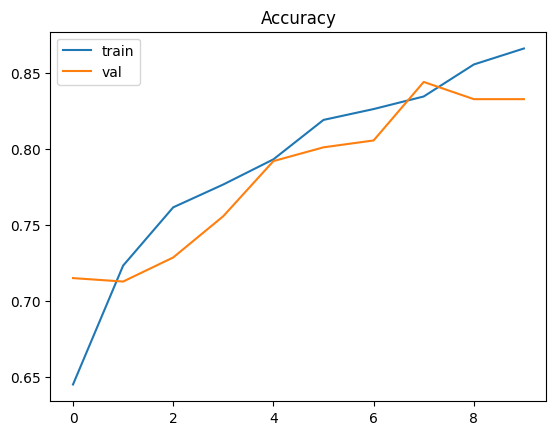

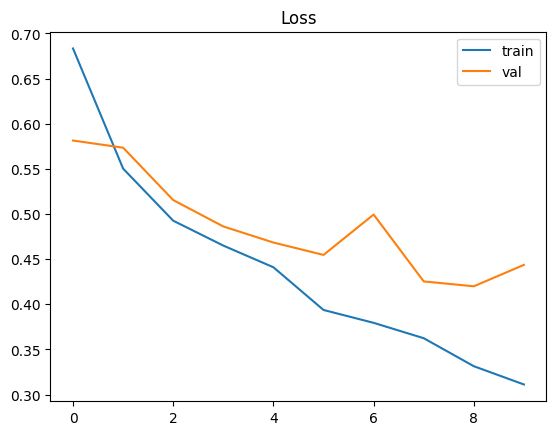

In [9]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train', 'val'])
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train', 'val'])
plt.title("Loss")
plt.show()

### Evaluate Model

In [10]:
test_loss, test_acc = cnn_model.evaluate(test_data)
print("Test Accuracy:", test_acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - accuracy: 0.8512 - loss: 0.3325
Test Accuracy: 0.8511627912521362


### Confusion Matrix

In [11]:
from sklearn.metrics import confusion_matrix, classification_report

preds = cnn_model.predict(test_data)
pred_labels = (preds > 0.5).astype(int)

print(confusion_matrix(test_data.classes, pred_labels))
print(classification_report(test_data.classes, pred_labels))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step
[[102  19]
 [ 13  81]]
              precision    recall  f1-score   support

           0       0.89      0.84      0.86       121
           1       0.81      0.86      0.84        94

    accuracy                           0.85       215
   macro avg       0.85      0.85      0.85       215
weighted avg       0.85      0.85      0.85       215



### Save Model

In [12]:
cnn_model.save("cnn_model.h5")

### Transfer Learning

In [13]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model_tl = models.Model(inputs=base_model.input, outputs=output)

### Compile & Train Transfer Model

In [14]:
model_tl.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_tl = model_tl.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 70s 780ms/step - accuracy: 0.9005 - loss: 0.2262 - val_accuracy: 0.9706 - val_loss: 0.0825
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 64s 765ms/step - accuracy: 0.9613 - loss: 0.0912 - val_accuracy: 0.9706 - val_loss: 0.0809
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 64s 759ms/step - accuracy: 0.9771 - loss: 0.0669 - val_accuracy: 0.9661 - val_loss: 0.0845
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 64s 762ms/step - accuracy: 0.9752 - loss: 0.0675 - val_accuracy: 0.9683 - val_loss: 0.0826
Epoch 5/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 68s 804ms/step - accuracy: 0.9838 - loss: 0.0439 - val_accuracy: 0.9729 - val_loss: 0.0854


### Save Best Model

In [15]:
model_tl.save("final_model.h5", include_optimizer=False)

### Predict on New Image

In [16]:
from tensorflow.keras.preprocessing import image

import os

img_path = "test/bird/" + os.listdir("test/bird")[0]

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model_tl.predict(img_array)

if prediction[0][0] > 0.5:
    print("Drone")
else:
    print("Bird")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Bird


### Streamlit App

In [18]:
import streamlit as st
import os
import gdown
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

st.title("Bird vs Drone Classifier")

# Download model if not present
if not os.path.exists("final_model.h5"):
    st.write("Downloading model...")
    url = "https://drive.google.com/uc?id=18-_QBibUvx3WIYZgMi_Sl4u0ar7gHSgI"
    gdown.download(url, "final_model.h5", quiet=False)

# Load model
model = load_model("final_model.h5", compile=False)

# Upload UI
uploaded_file = st.file_uploader("Upload an image", type=["jpg", "png", "jpeg"])

if uploaded_file is not None:
    img = image.load_img(uploaded_file, target_size=(224,224))
    st.image(img, caption="Uploaded Image")

    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)

    if pred[0][0] > 0.5:
        st.success("Drone Detected")
    else:
        st.success("Bird Detected")

2026-04-17 00:09:53.132 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 00:09:53.133 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 00:09:53.134 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 00:09:53.934 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 00:09:53.935 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 00:09:53.935 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 00:09:53.937 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 00:09:53.939 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [1]:
from ultralytics import YOLO
print("YOLOv8 ready")


Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\updes\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8 ready
